In [4]:
import pandas as pd
import numpy as np
import re
import warnings
import os
import glob

warnings.filterwarnings("ignore")


crypto_keywords = {
    'Bitcoin': ['BTC', 'Bitcoin', 'Satoshi', 'BTCUSD', 'BTCUSDT'],
    'Ethereum': [' ETH ', 'Ethereum', 'Vitalik', 'ETHUSD', 'ETHUSDT'],
    'Cardano': [' ADA ','Cardano', 'ADAUSD', 'ADAUSDT'],
    'Solana': [' SOL ', 'Solana', 'SOLUSD', 'SOLUSDT'],
    'Ripple': ['XRP', 'Ripple', 'XRPUSD', 'XRPUSDT'],
    'Polkadot': [' DOT ', 'Polkadot', 'DOTUSD', 'DOTUSDT'],
    'Litecoin': ['LTC', 'Litecoin', 'LTCUSD', 'LTCUSDT'],
    'Dogecoin': ['DOGE', 'Dogecoin', 'DOGEUSD', 'DOGEUSDT'],
    'Binance Coin': ['BNB', 'Binance', 'BNBUSD', 'BNBUSDT'],
    'Polygon': ['MATIC', 'Polygon', 'MATICUSD', 'MATICUSDT'],
    'Shiba Inu': ['SHIB', 'Shiba', 'SHIBUSD', 'SHIBUSDT'],
    'Avalanche': ['AVAX', 'Avalanche', 'AVAXUSD', 'AVAXUSDT'],
    'Uniswap': [' UNI ', 'Uniswap', 'UNIUSD', 'UNIUSDT'],
    'Chainlink': ['Chainlink', 'LINKUSD', 'LINKUSDT'],
    'Stellar': ['XLM', 'Stellar', 'XLMUSD', 'XLMUSDT'],
    'Tether': ['USDT', 'Tether'],
    'USD Coin': ['USDC', 'USD Coin'],
    'Tron': ['TRX', 'Tron', 'TRXUSD', 'TRXUSDT'],
    'Cosmos': ['ATOM', 'Cosmos', 'ATOMUSD', 'ATOMUSDT'],
    'VeChain': ['VeChain', 'VETUSD', 'VETUSDT'],
    'Algorand': ['Algorand', 'ALGOUSD', 'ALGOUSDT'],
    'Tezos': ['XTZ', 'Tezos', 'XTZUSD', 'XTZUSDT'],
    'Aave': ['AAVE', 'Aave', 'AAVEUSD', 'AAVEUSDT'],
    'Monero': ['XMR', 'Monero', 'XMRUSD', 'XMRUSDT'],
    'Bitcoin Cash': ['BCH', 'Bitcoin Cash', 'BCHUSD', 'BCHUSDT'],
    'EOS': ['EOS', 'EOSUSD', 'EOSUSDT'],
    'Zcash': [ 'Zcash', 'ZECUSD', 'ZECUSDT'],
    'IOTA': ['MIOTA', 'IOTA', 'MIOTAUSD', 'MIOTAUSDT'],
    'Dash': ['DASHUSD', 'DASHUSDT'],
    'Near Protocol': ['NEAR', 'Near', 'NEARUSD', 'NEARUSDT'],
    'Filecoin': ['FIL', 'Filecoin', 'FILUSD', 'FILUSDT'],
    'Elrond': ['EGLD', 'Elrond', 'EGLDUSD', 'EGLDUSDT'],
    'Theta': ['THETA', 'Theta', 'THETAUSD', 'THETAUSDT']}

def count_cryptos(comment):
    if not isinstance(comment, str):  # Handle non-string input
        return 0

    mentioned_cryptos = set()
    for crypto, keywords in crypto_keywords.items():
        for keyword in keywords:
            # Match word boundaries and allow punctuation around the keyword
            if re.search(rf'\b{re.escape(keyword)}\b', comment, re.IGNORECASE):
                mentioned_cryptos.add(crypto)
    return len(mentioned_cryptos)


# Function to filter comments mentioning multiple cryptos
def filter_single_crypto_comments(df):
    df['crypto_count'] = df['comment'].apply(count_cryptos)
    initial_count = len(df)
    df = df[df['crypto_count'] == 1]
    print(f"Removed {initial_count - len(df)} comments mentioning multiple cryptos.")
    df.drop(columns=['crypto_count'], inplace=True)
    return df

# Function to remove exact duplicates
def remove_exact_duplicates(df):
    initial_count = len(df)
    df.drop_duplicates(subset=['comment'], inplace=True)
    print(f"Removed {initial_count - len(df)} exact duplicate comments.")
    return df


# Function to remove comments with links
def remove_comments_with_links(df):
    initial_count = len(df)
    df = df[~df['comment'].str.contains(r'http[s]?://', na=False)]
    print(f"Removed {initial_count - len(df)} comments with links.")
    return df

# Function to remove too short comments
def remove_too_short_comments(df, min_words=4):
    initial_count = len(df)
    df = df[df['comment'].str.split().str.len() >= min_words]
    print(f"Removed {initial_count - len(df)} too short comments.")
    return df

def clean_comment_text(comment):
    """
    Cleans a single comment by removing extra spaces, stray punctuation, 
    formatting artifacts, URLs, tags, mentions, and excessive punctuation.
    
    Args:
        comment (str): The input comment string.
    
    Returns:
        str: The cleaned comment.
    """
    if not isinstance(comment, str):
        return ""  # Return an empty string for non-string inputs

    # Remove mentions (e.g., @user) and hashtags
    comment = re.sub(r"@\w+|#\w+", "", comment)

    # Remove stray formatting artifacts like \n, \t
    comment = re.sub(r"[\n\t]", " ", comment)

    # Remove excessive punctuation (e.g., "!!!" -> "!")
    comment = re.sub(r"([!?.]){2,}", r"\1", comment)

    # Remove any remaining non-alphanumeric characters except for standard punctuation
    comment = re.sub(r"[^a-zA-Z0-9\s.,!?']", "", comment)

    # Remove extra spaces
    comment = re.sub(r"\s+", " ", comment).strip()

    return comment


# Main cleaning function
def clean_df(df):
    """Cleans and preprocesses the input DataFrame."""
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df.dropna(subset=['date'], inplace=True)
    df['date'] = df['date'].dt.date
    df.drop_duplicates(inplace=True)

    # Apply filters
    df = filter_single_crypto_comments(df)
    df = remove_exact_duplicates(df)
    df = remove_comments_with_links(df)
    df['comment'] = df['comment'].apply(clean_comment_text)
    df = remove_too_short_comments(df)


    df.sort_values(by='date', inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


# asset = 'Cardano'

# # Load and clean data
# sentiment_path = '/Users/gabo/Documents/Thesis/Data/Text/Reddit/2023/Comments/Cryptos/Sentiment/Cardano/Filtered/CryptoCurrency_Cardano_sentiment.csv'
# df = clean_df(pd.read_csv(sentiment_path,lineterminator='\n'))

In [6]:
input_folder = '/Users/gabo/Documents/Thesis/Data/Text/Reddit/2023/Comments/Cryptos/Bitcoin/Filtered/*'
output_folder = '/Users/gabo/Documents/Thesis/Data/Text/Reddit/2023/Comments/Cryptos/Bitcoin/Cleaned'
file_list = glob.glob(input_folder)
file_list = [path for path in file_list if not path.startswith(output_folder)]

for file_path in file_list:
    file_name = os.path.basename(file_path)
    file_name_short = os.path.splitext(file_name)[0]
    print(file_name_short)
   
    input_df = pd.read_csv(file_path,lineterminator='\n',header=None)   

    input_df = input_df[[1, 4]] #for comments it's input_df[[1, 4]] for submissions input_df[[1, 2]]
    input_df.columns = ['date', 'comment']
    input_df['date'] = pd.to_datetime(input_df['date'])

    # Filter rows where 'date' is greater than or equal to 2020-01-01
    filtered_df = input_df[input_df['date'] >= '2020-01-01']    
    cleaned_df = clean_df(filtered_df)
    
    start = len(filtered_df)
    end=len(cleaned_df)
    removed = start-end
          
    print("Removed "+ str(removed) + ' observations of ' + str(start))
    output_file_name = f'{output_folder}/{file_name_short}_cleaned.csv'
    cleaned_df.to_csv(output_file_name,index=False)


Bitcoin_Bitcoin
Removed 82651 comments mentioning multiple cryptos.
Removed 27595 exact duplicate comments.
Removed 78530 comments with links.
Removed 6058 too short comments.
Removed 194834 observations of 1216135
CryptoCurrency_Bitcoin
Removed 404247 comments mentioning multiple cryptos.
Removed 12714 exact duplicate comments.
Removed 70361 comments with links.
Removed 9306 too short comments.
Removed 496628 observations of 1617977
wallstreetbets_Bitcoin
Removed 3787 comments mentioning multiple cryptos.
Removed 521 exact duplicate comments.
Removed 1108 comments with links.
Removed 954 too short comments.
Removed 6370 observations of 39060
btc_Bitcoin
Removed 103989 comments mentioning multiple cryptos.
Removed 469 exact duplicate comments.
Removed 16359 comments with links.
Removed 474 too short comments.
Removed 121291 observations of 194363
CryptoMoonShots_Bitcoin
Removed 1158 comments mentioning multiple cryptos.
Removed 19 exact duplicate comments.
Removed 182 comments with lin

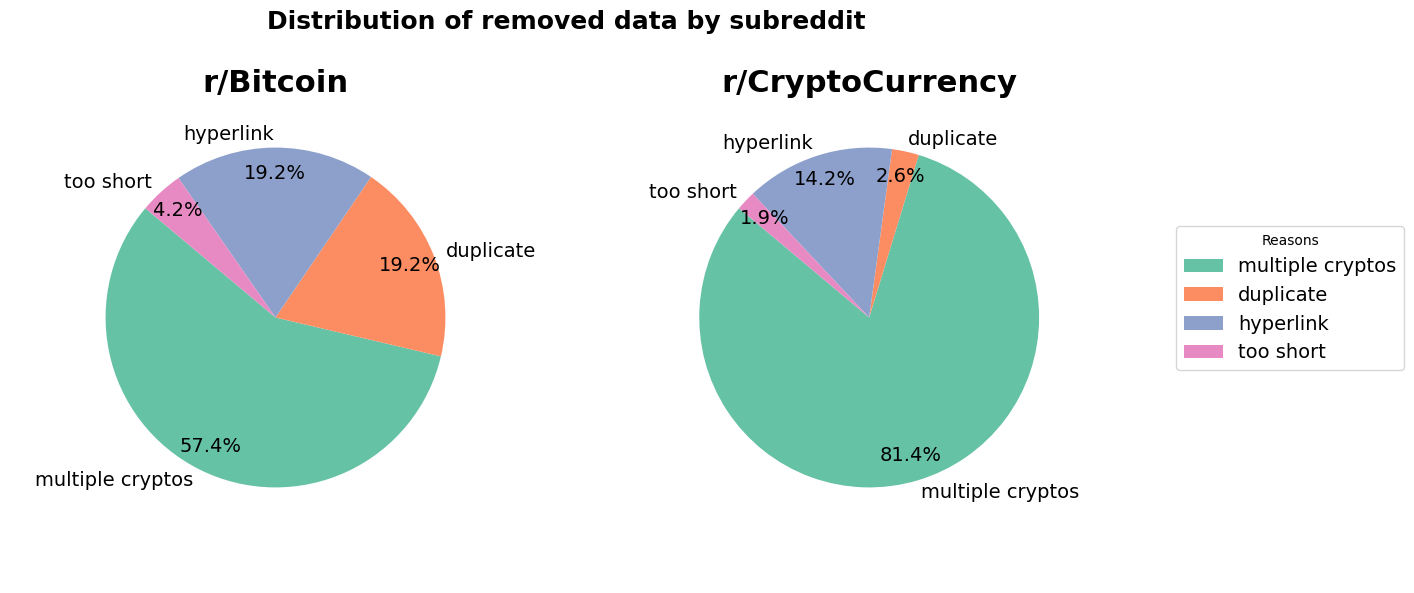

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Data from the table
data = {
    'Reason': ['multiple cryptos', 'duplicate', 'hyperlink', 'too short'],
    'r/Bitcoin': [82651, 27595, 27595, 6058],
    'r/CryptoCurrency': [404247, 12714, 70361, 9306]
    #'r/Reddit': [103989, 469, 16359, 474]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Set the 'Reason' column as the index
df.set_index('Reason', inplace=True)

# Plotting Pie Charts for each subreddit
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

subreddits = df.columns
colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']

for i, (ax, subreddit) in enumerate(zip(axes, subreddits)):
    wedges, texts, autotexts = ax.pie(
        df[subreddit],
        labels=df.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=140,
        radius=0.8,  # Makes the pies smaller
        labeldistance=1.075,# Moves the labels further away from the center
        pctdistance=0.85
    )

    # Move the title lower
    ax.text(0, 1.1, subreddit, ha='center', va='center', fontsize=22, fontweight='bold')

    # Adjust text size within the pie chart
    for text in texts + autotexts:
        text.set_fontsize(14)
    for autotext in autotexts:
        autotext.set_fontsize(14)

# Adding one legend outside the subplots with larger text
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Reasons", loc="center left", bbox_to_anchor=(1, 0.5), fontsize=14)

# Set the suptitle with a larger font size
plt.suptitle('Distribution of removed data by subreddit', fontsize=18,fontweight='bold')

plt.tight_layout()
plt.show()


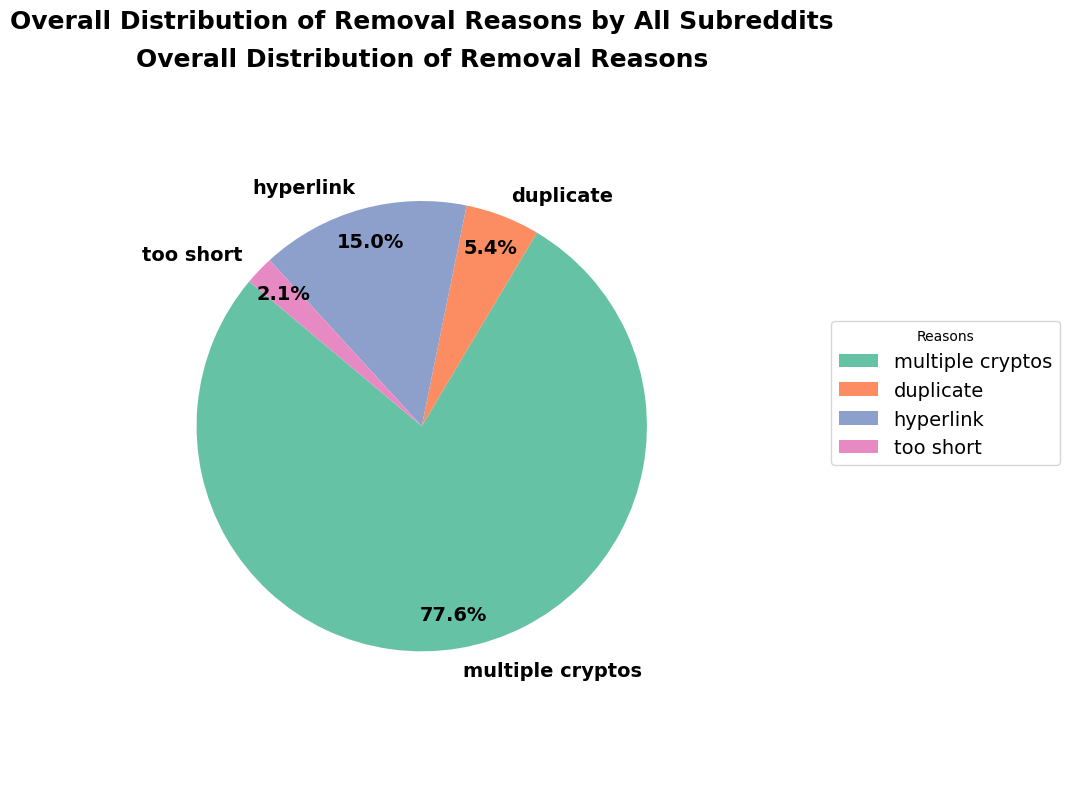

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Data from the table
data = {
    'Reason': ['multiple cryptos', 'duplicate', 'hyperlink', 'too short'],
    'r/Bitcoin': [82651, 27595, 27595, 6058],
    'r/CryptoCurrency': [404247, 12714, 70361, 9306],
    'r/Reddit': [103989, 469, 16359, 474]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Set the 'Reason' column as the index
df.set_index('Reason', inplace=True)

# Sum the values of the subreddits across each reason
total_values = df.sum(axis=1)

# Plotting Overall Pie Chart
fig, ax = plt.subplots(figsize=(8, 8))

colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']

# Creating the pie chart
wedges, texts, autotexts = ax.pie(
    total_values,
    labels=total_values.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    radius=0.8,  # Makes the pie smaller
    labeldistance=1.1,  # Moves the labels further away from the center
    pctdistance=0.85
)

# Adjust text size within the pie chart
for text in texts + autotexts:
    text.set_fontsize(14)
    text.set_fontweight('bold')
for autotext in autotexts:
    autotext.set_fontsize(14)
    autotext.set_fontweight('bold')

# Set the title of the pie chart
ax.set_title('Overall Distribution of Removal Reasons', fontsize=18, fontweight='bold')

# Adding one legend outside the pie chart
fig.legend(wedges, total_values.index, title="Reasons", loc="center left", bbox_to_anchor=(1, 0.5), fontsize=14)

# Set the suptitle with a larger font size
plt.suptitle('Overall Distribution of Removal Reasons by All Subreddits', fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()
